In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../Data/Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())


Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)

In [10]:
df['Churn_Label'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nShape after clean:", df.shape)
print("Ready to analyze!")



Shape after clean: (7032, 22)
Ready to analyze!


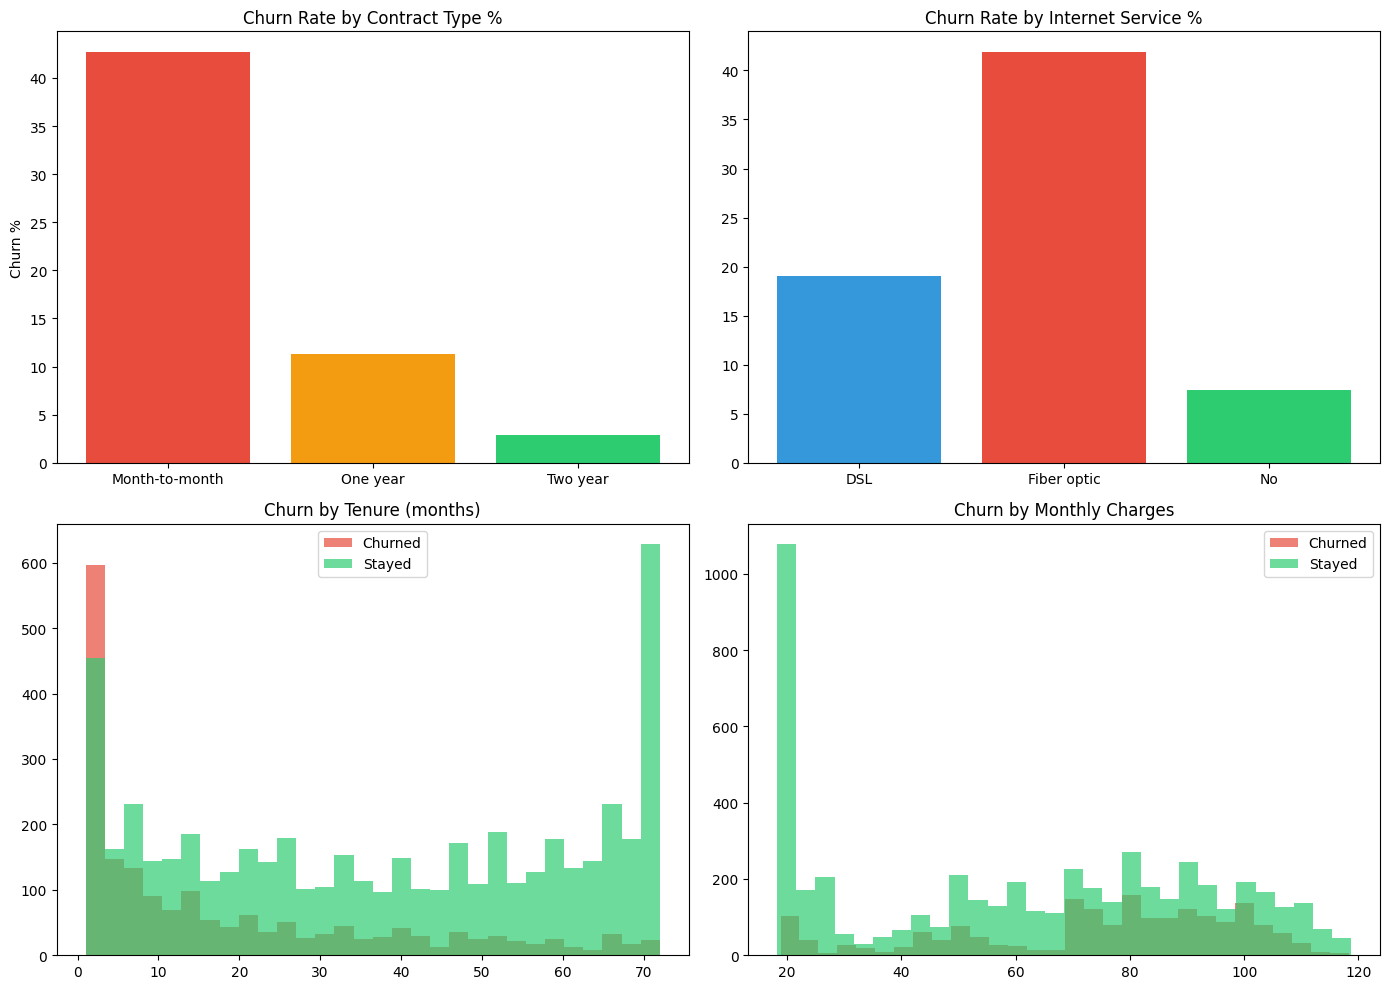

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
contract_churn = df.groupby('Contract')['Churn_Label'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[0,0].set_title('Churn Rate by Contract Type %')
axes[0,0].set_ylabel('Churn %')
internet_churn = df.groupby('InternetService')['Churn_Label'].mean() * 100
axes[0,1].bar(internet_churn.index, internet_churn.values, color=['#3498db','#e74c3c','#2ecc71'])
axes[0,1].set_title('Churn Rate by Internet Service %')
axes[1,0].hist(df[df['Churn']=='Yes']['tenure'], bins=30, color='#e74c3c', alpha=0.7, label='Churned')
axes[1,0].hist(df[df['Churn']=='No']['tenure'], bins=30, color='#2ecc71', alpha=0.7, label='Stayed')
axes[1,0].set_title('Churn by Tenure (months)')
axes[1,0].legend()
axes[1,1].hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=30, color='#e74c3c', alpha=0.7, label='Churned')
axes[1,1].hist(df[df['Churn']=='No']['MonthlyCharges'], bins=30, color='#2ecc71', alpha=0.7, label='Stayed')
axes[1,1].set_title('Churn by Monthly Charges')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../Data/churn_drivers.png')
plt.show()


In [16]:
print("=== KEY FINDINGS ===")
print(f"Overall Churn Rate: {df['Churn_Label'].mean()*100:.1f}%")
print(f"Month-to-month churn: {df[df['Contract']=='Month-to-month']['Churn_Label'].mean()*100:.1f}%")
print(f"Fiber optic churn: {df[df['InternetService']=='Fiber optic']['Churn_Label'].mean()*100:.1f}%")
print(f"New customer churn (0-12 months): {df[df['tenure']<=12]['Churn_Label'].mean()*100:.1f}%")


=== KEY FINDINGS ===
Overall Churn Rate: 26.6%
Month-to-month churn: 42.7%
Fiber optic churn: 41.9%
New customer churn (0-12 months): 47.7%


In [17]:
df.to_csv('../Data/churn_clean.csv', index=False)
print("\n✅ Exported: churn_clean.csv - Ready for Tableau!")


✅ Exported: churn_clean.csv - Ready for Tableau!
